# Assignment 1: Sampling and Reproducibility

The code at the end of this file explores contact tracing data about an outbreak of the flu, and demonstrates the dangers of incomplete and non-random samples. This assignment is modified from [Contact tracing can give a biased sample of COVID-19 cases](https://andrewwhitby.com/2020/11/24/contact-tracing-biased/) by Andrew Whitby.

Examine the code below. Identify all stages at which sampling is occurring in the model. Describe in words the sampling procedure, referencing the functions used, sample size, sampling frame, any underlying distributions involved. 


MY RESPONSE: In reviewing the code, it seems to me that each person in the population has the same probability of infection, and that infection is modelled as a binary outcome (infected or not). Infections are assigned using simple random sampling without replacement, meaning that once a person is selected as infected, they cannot be selected again.

Because the sampling is done without replacement, the draws are technically dependent, and the probability of infection changes slightly with each draw. For this reason, the underlying distribution is more accurately described as hypergeometric, which is commonly used in SRSWOR of a finite population.

That said, the model still assumes infection occurs randomly and uniformly across individuals, with no preference for weddings or brunches. This makes the infection process conceptually similar to a Bernoulli (model sitatuons where you prepeat the same experiment over and over again, and there are only two possible outcome = infected/not infected. Equal chance of being one or the other) process at the individual level, even though the exact mechanics align better with a hypergeometric distribution. I believe that any bias observed later in the results is introduced by the contact-tracing process rather than by the infection assignment itself.

Event attendance and infection assignment (fixed population structure)
* Sampling frame: all 1,000 individuals in the population
(200 wedding attendees, 800 brunch attendees)
* Sample size: 10% of the population (ATTACK_RATE = 0.10 --> 100 individuals)
* Sampling method: simple random sampling without replacement
* Underlying distribution: hypergeometric, due to dependent draws in a finite population

Primary contact tracing
* Sampling frame: infected individuals only
* Sample size: approximately 20% of infected individuals (TRACE_SUCCESS = 0.20)
* Sampling method: independent Bernoulli trials applied to infected cases
* Underlying distribution: Binomial

Secondary contact tracing (biased event-level amplification)
* Sampling frame: events (weddings or brunches) with traced infections
* Threshold: at least two traced cases
* Effect: all infected individuals from qualifying events are marked as traced

Repeated simulation (Monte Carlo sampling)

Finally, the entire process is repeated across 1,000 simulations.

* Sampling method: Monte Carlo simulation using repeated random sampling
* Purpose: to approximate the distribution of outcomes under repeated realizations of the same stochastic process

Modify the number of repetitions in the simulation to 10 and 100 (from the original 1000). Run the script multiple times and observe the outputted graphs. Comment on the reproducibility of the results.

MY RESPONSE: In completing this portion of the assignment, I noticed that, as the number of repetitions increases, the results become more reproducible and stable across runs (see the graph outputs in file... sampling\02_activities\assignments\Assignment 1 Outputs). This is a visible manifestation of the Law of Large Numbers.

When the repetitions were 10, the graphs varied noticeably each time I ran the code, with the centre shifting and the shapes looking blocky/lumpy. Outliers near 0 or with high probability occurred more often.

When the repetitions were 100, the distributions had a more consistent shape, with the centre also being more consistent. There was still some visibility, but much smaller.

When I ran the original code at 1000, the graphs were the most similar to each other, with a stable centre, as the results were no longer sensitive to individual random draws.

Alter the code so that it is reproducible. Describe the changes you made to the code and how they affected the reproducibility of the script. The script needs to produce the same output when run multiple times.

MY RESPONSE: At first I tried increasing the number of repetitions (e.g., to 10,000) because the graphs looked more stable across runs. This helped reduce randomness in the overall shape (less Monte Carlo noise), but it didn’t make the script fully reproducible, the output still changed each time because the random number generator was not fixed.

To make the script reproducible, I set a fixed random seed using NumPy’s default_rng() and used that generator for both the infection sampling (rng.choice) and the tracing step (rng.random). With a fixed seed, the same sequence of random draws occurs each run, so the simulation results and the output plot are identical when rerun. I also fixed the graph bin edges the x-axis limits (first when I was trouble shooting why my random seed wasm't working - hint I put it in my function, which I fixed) to ensure the plot appearance stays consistent.

## Code

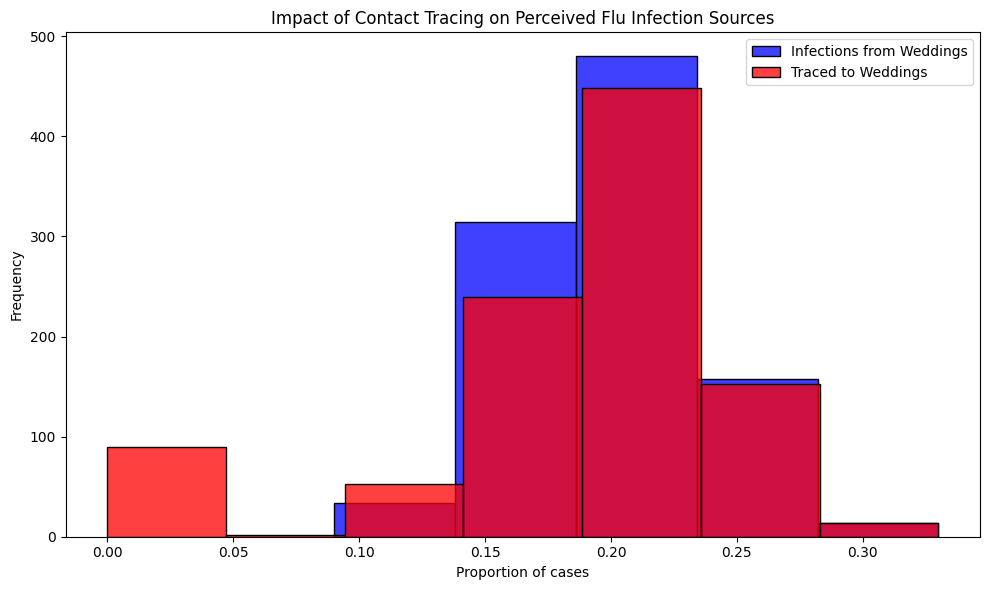

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Suppressing FutureWarnings to maintain a clean output. This is specifically to ignore warnings about
# deprecated features in the libraries we're using (e.g., 'use_inf_as_na' option in Pandas, used by Seaborn),
# which we currently have no direct control over. This action is taken to ensure that our output remains
# focused on relevant information, acknowledging that we rely on external library updates to fully resolve
# these deprecations. Always consider reviewing and removing this suppression after significant library updates.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Constants representing the parameters of the model
ATTACK_RATE = 0.10
TRACE_SUCCESS = 0.20
SECONDARY_TRACE_THRESHOLD = 2

# completing question 3 - make it reproducible
# I am going to control randomness by setting a seed
# moving this out of the funtion so it can acutally work

SEED = 42
rng = np.random.default_rng(SEED)

def simulate_event(rng): # question 3 - updating this control randomness
  """
  Simulates the infection and tracing process for a series of events.
  
  This function creates a DataFrame representing individuals attending weddings and brunches,
  infects a subset of them based on the ATTACK_RATE, performs primary and secondary contact tracing,
  and calculates the proportions of infections and traced cases that are attributed to weddings.
  
  Parameters:
  - m: Dummy parameter for iteration purposes.
  
  Returns:
  - A tuple containing the proportion of infections and the proportion of traced cases
    that are attributed to weddings.
  """
    
  # Create DataFrame for people at events with initial infection and traced status
  events = ['wedding'] * 200 + ['brunch'] * 800
  ppl = pd.DataFrame({
      'event': events,
      'infected': False,
      'traced': np.nan  # Initially setting traced status as NaN
  })

  # Explicitly set 'traced' column to nullable boolean type
  ppl['traced'] = ppl['traced'].astype(pd.BooleanDtype())

  # Infect a random subset of people
  infected_indices = rng.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)  # question 3 - updating this to control randomness
  ppl.loc[infected_indices, 'infected'] = True

  # Primary contact tracing: randomly decide which infected people get traced
  ppl.loc[ppl['infected'], 'traced'] = rng.random(sum(ppl['infected'])) < TRACE_SUCCESS  # question 3 - updating this to control randomness

  # Secondary contact tracing based on event attendance
  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True

  # Calculate proportions of infections and traces attributed to each event type
  ppl['event_type'] = ppl['event'].str[0]  # 'w' for wedding, 'b' for brunch
  wedding_infections = sum(ppl['infected'] & (ppl['event_type'] == 'w'))
  brunch_infections = sum(ppl['infected'] & (ppl['event_type'] == 'b'))
  p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections)

  wedding_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'w'))
  brunch_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'b'))
  p_wedding_traces = wedding_traces / (wedding_traces + brunch_traces)

  return p_wedding_infections, p_wedding_traces

# Run the simulation 1000 times
results = [simulate_event(rng) for _ in range(1000)]  #for question 2, I am modifiying this to 10 and 100 and will save outputs to review, for question 3 tried increasing it to 10,000
props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

# Plotting the results
bins = np.arange(0, 0.36, 0.05) #question 3 - locking in bin edges and axis scaling
plt.figure(figsize=(10, 6))
sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05, kde=False, label='Infections from Weddings')
sns.histplot(props_df['Traces'], color="red", alpha=0.75, binwidth=0.05, kde=False, label='Traced to Weddings')
plt.xlabel("Proportion of cases")
plt.ylabel("Frequency")
plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
plt.legend()
plt.tight_layout()
plt.show()

# :) hello

## Criteria

|Criteria|Complete|Incomplete|
|--------|----|----|
|Alteration of the code|The code changes made, made it reproducible.|The code is still not reproducible.|
|Description of changes|The author answered questions and explained the reasonings for the changes made well.|The author did not answer questions or explain the reasonings for the changes made well.|

## Submission Information
🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `23:59 - 02 February 2026`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This markdown file (`a1_sampling_and_reproducibility.ipynb`) should be populated with the code changed.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/sampling/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

#### Checklist:
- [ ] Create a branch called `assignment-1`.
- [ ] Ensure that the repository is public.
- [ ] Review [the PR description guidelines](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md#guidelines-for-pull-request-descriptions) and adhere to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via the help channel in Slack. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
